# Vouzela Wildfire (Portugal) — TROPOMI Analysis, 2–3 July 2026

This notebook loads and analyzes Sentinel-5P TROPOMI data downloaded by
`scripts/download_tropomi.py` (or the `download-tropomi.yml` GitHub Action)
for the **Vouzela wildfire** event:

- **2 July 2026** — fire ignition near Tourelhe, Vouzela (Viseu district)
- **3 July 2026, 10:38 UTC** — Sentinel-3 captures the ~620 km smoke plume

For each of the six TROPOMI species (**CO, NO₂, SO₂, HCHO, CH₄, O₃**) this
notebook:

1. Loads all orbit files available for 2 July and 3 July 2026
2. Applies the standard quality filter (`qa_value >= 0.75`)
3. Prints summary statistics (file count, mean, max, valid-pixel coverage)
4. Plots a map for each day
5. Plots a side-by-side 2 July vs 3 July comparison to show the plume forming
6. Builds a summary table across all six species

**Before running:** make sure `data/` (at the repo root) is populated —
run the download script or the GitHub Action and unzip its artifact into
`data/` first. Cells below skip gracefully (with a printed warning) for any
species/day with no files found, so partial data still produces output.


In [1]:
import os
import glob
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

DATA_DIR = os.path.join("..", "data")  # repo_root/data — adjust if running from elsewhere

print("Looking for data in:", os.path.abspath(DATA_DIR))
print("Exists:", os.path.isdir(DATA_DIR))


Looking for data in: /home/claude/vouzela-wildfire-2026/data
Exists: True


In [2]:
# TROPOMI L2 variable names (inside the 'PRODUCT' group) and a display-friendly
# label/colormap/unit for each species.
SPECIES = {
    "CO": {
        "var": "carbonmonoxide_total_column",
        "label": "CO total column",
        "unit": "mol/m²",
        "cmap": "inferno",
        "desc": "Carbon Monoxide — primary wildfire tracer",
    },
    "NO2": {
        "var": "nitrogendioxide_tropospheric_column",
        "label": "NO2 tropospheric column",
        "unit": "mol/m²",
        "cmap": "magma",
        "desc": "Nitrogen Dioxide — combustion indicator",
    },
    "SO2": {
        "var": "sulfurdioxide_total_vertical_column",
        "label": "SO2 total column",
        "unit": "mol/m²",
        "cmap": "plasma",
        "desc": "Sulphur Dioxide — fire/industrial marker",
    },
    "HCHO": {
        "var": "formaldehyde_tropospheric_vertical_column",
        "label": "HCHO tropospheric column",
        "unit": "mol/m²",
        "cmap": "viridis",
        "desc": "Formaldehyde — VOC biomass burning product",
    },
    "CH4": {
        "var": "methane_mixing_ratio_bias_corrected",
        "label": "CH4 mixing ratio (bias corrected)",
        "unit": "ppb",
        "cmap": "cividis",
        "desc": "Methane — greenhouse gas, elevated in fire plumes",
    },
    "O3": {
        "var": "ozone_total_vertical_column",
        "label": "O3 total column",
        "unit": "mol/m²",
        "cmap": "cubehelix",
        "desc": "Ozone — secondary pollutant, enhanced downwind",
    },
}

DATES = {
    "2026-07-02": "2 July — ignition day",
    "2026-07-03": "3 July — Sentinel-3 plume image day",
}

for sp, info in SPECIES.items():
    print(f"{sp:5s} -> {info['var']:45s} ({info['desc']})")


CO    -> carbonmonoxide_total_column                   (Carbon Monoxide — primary wildfire tracer)
NO2   -> nitrogendioxide_tropospheric_column           (Nitrogen Dioxide — combustion indicator)
SO2   -> sulfurdioxide_total_vertical_column           (Sulphur Dioxide — fire/industrial marker)
HCHO  -> formaldehyde_tropospheric_vertical_column     (Formaldehyde — VOC biomass burning product)
CH4   -> methane_mixing_ratio_bias_corrected           (Methane — greenhouse gas, elevated in fire plumes)
O3    -> ozone_total_vertical_column                   (Ozone — secondary pollutant, enhanced downwind)


In [3]:
def find_files(species, date_str):
    """Return .nc files for a species whose filename encodes the given date (YYYY-MM-DD)."""
    species_dir = os.path.join(DATA_DIR, species)
    if not os.path.isdir(species_dir):
        return []
    date_compact = date_str.replace("-", "")
    all_files = glob.glob(os.path.join(species_dir, "*.nc"))
    # TROPOMI filenames embed the sensing start date as e.g. ..._20260702T...
    return sorted(f for f in all_files if date_compact in os.path.basename(f))


def load_variable(fpath, varname, qa_threshold=0.75):
    """Open one TROPOMI file, apply the QA filter, and return (lon, lat, values) as flat arrays."""
    try:
        ds = xr.open_dataset(fpath, group="PRODUCT")
    except Exception as e:
        print(f"    could not open {os.path.basename(fpath)}: {e}")
        return None, None, None

    if varname not in ds:
        print(f"    variable '{varname}' not found in {os.path.basename(fpath)}")
        ds.close()
        return None, None, None

    var = ds[varname]
    qa = ds["qa_value"] if "qa_value" in ds else None

    lon = ds["longitude"].values.ravel()
    lat = ds["latitude"].values.ravel()
    vals = var.values.ravel()

    if qa is not None:
        qa_vals = qa.values.ravel()
        mask = qa_vals >= qa_threshold
        lon, lat, vals = lon[mask], lat[mask], vals[mask]

    valid = ~np.isnan(vals)
    ds.close()
    return lon[valid], lat[valid], vals[valid]


def load_species_day(species, date_str):
    """Load & concatenate all orbit files for one species on one date. Returns lon, lat, vals arrays (possibly empty)."""
    files = find_files(species, date_str)
    info = SPECIES[species]
    print(f"  {species} / {date_str}: {len(files)} file(s) found")
    if not files:
        return np.array([]), np.array([]), np.array([])

    lons, lats, vals = [], [], []
    for f in files:
        lo, la, v = load_variable(f, info["var"])
        if lo is not None and len(lo):
            lons.append(lo); lats.append(la); vals.append(v)

    if not vals:
        return np.array([]), np.array([]), np.array([])

    return np.concatenate(lons), np.concatenate(lats), np.concatenate(vals)


In [4]:
results = {}  # results[species][date] = dict(lon, lat, vals, stats)

for species, info in SPECIES.items():
    print("=" * 70)
    print(f"{species} — {info['desc']}")
    print("=" * 70)
    results[species] = {}

    for date_str, date_label in DATES.items():
        lon, lat, vals = load_species_day(species, date_str)
        stats = {
            "n_points": int(vals.size),
            "mean": float(np.mean(vals)) if vals.size else None,
            "max": float(np.max(vals)) if vals.size else None,
            "min": float(np.min(vals)) if vals.size else None,
        }
        results[species][date_str] = {"lon": lon, "lat": lat, "vals": vals, "stats": stats}

        print(f"    {date_label}:")
        if stats["n_points"] == 0:
            print(f"      no valid (QA-filtered) data available yet")
        else:
            print(f"      valid pixels : {stats['n_points']:,}")
            print(f"      mean         : {stats['mean']:.4g} {info['unit']}")
            print(f"      max          : {stats['max']:.4g} {info['unit']}")
            print(f"      min          : {stats['min']:.4g} {info['unit']}")
    print()


CO — Carbon Monoxide — primary wildfire tracer
  CO / 2026-07-02: 0 file(s) found
    2 July — ignition day:
      no valid (QA-filtered) data available yet
  CO / 2026-07-03: 0 file(s) found
    3 July — Sentinel-3 plume image day:
      no valid (QA-filtered) data available yet

NO2 — Nitrogen Dioxide — combustion indicator
  NO2 / 2026-07-02: 0 file(s) found
    2 July — ignition day:
      no valid (QA-filtered) data available yet
  NO2 / 2026-07-03: 0 file(s) found
    3 July — Sentinel-3 plume image day:
      no valid (QA-filtered) data available yet

SO2 — Sulphur Dioxide — fire/industrial marker
  SO2 / 2026-07-02: 0 file(s) found
    2 July — ignition day:
      no valid (QA-filtered) data available yet
  SO2 / 2026-07-03: 0 file(s) found
    3 July — Sentinel-3 plume image day:
      no valid (QA-filtered) data available yet

HCHO — Formaldehyde — VOC biomass burning product
  HCHO / 2026-07-02: 0 file(s) found
    2 July — ignition day:
      no valid (QA-filtered) data ava

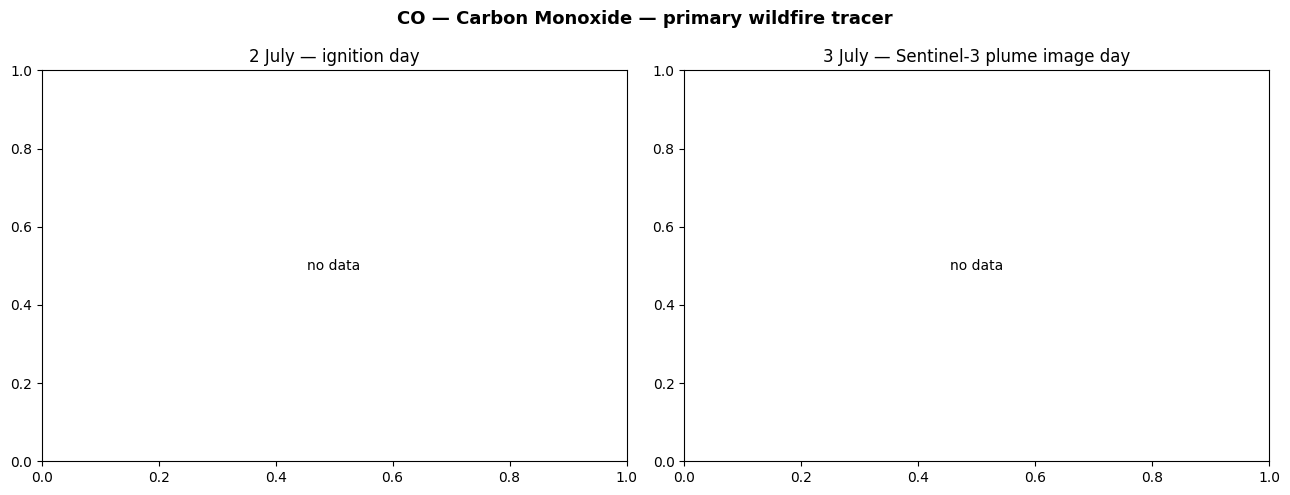

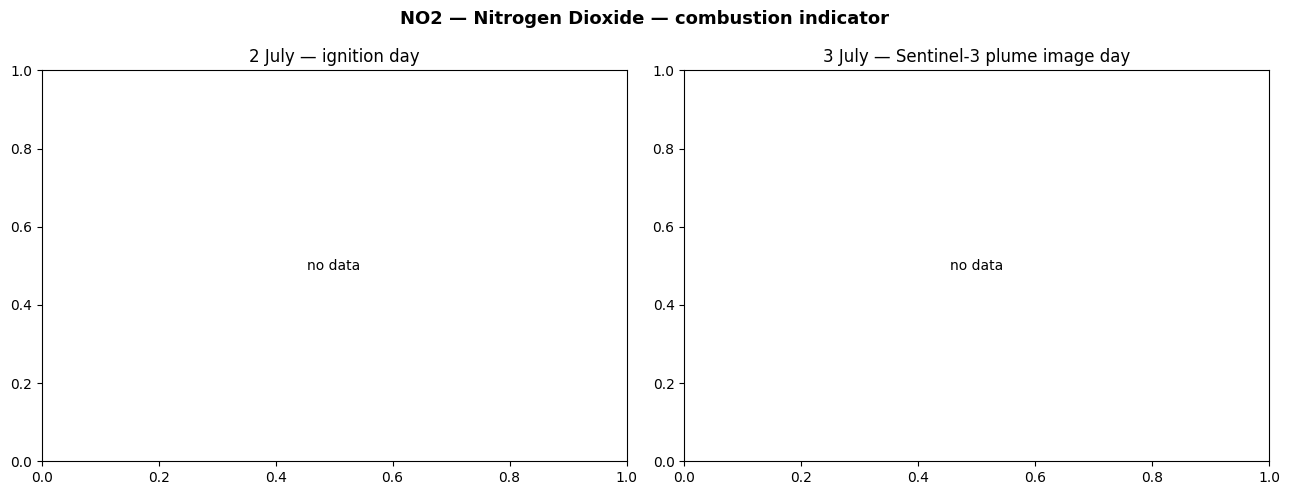

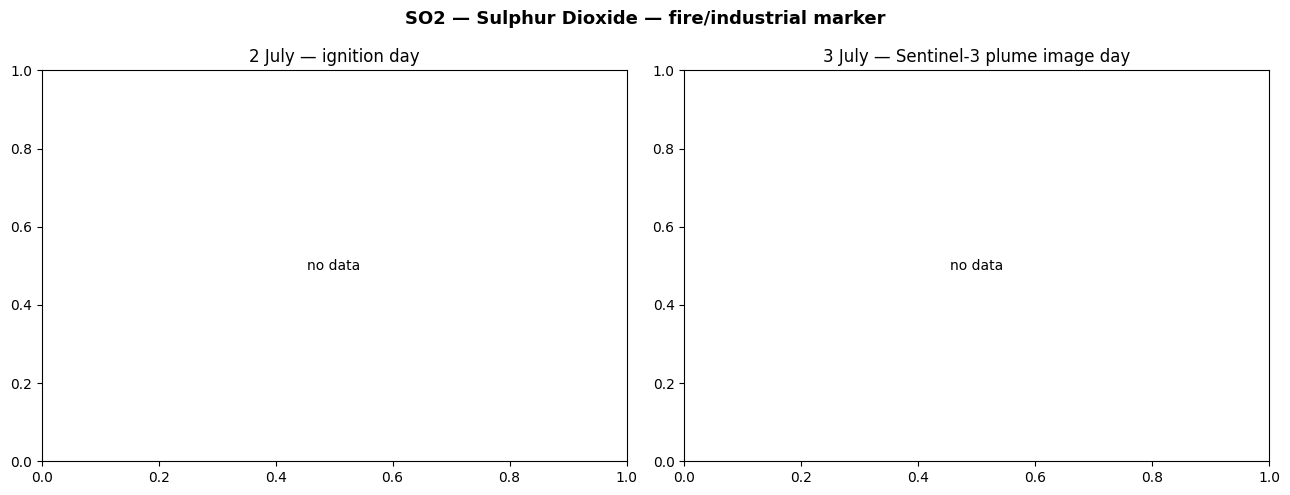

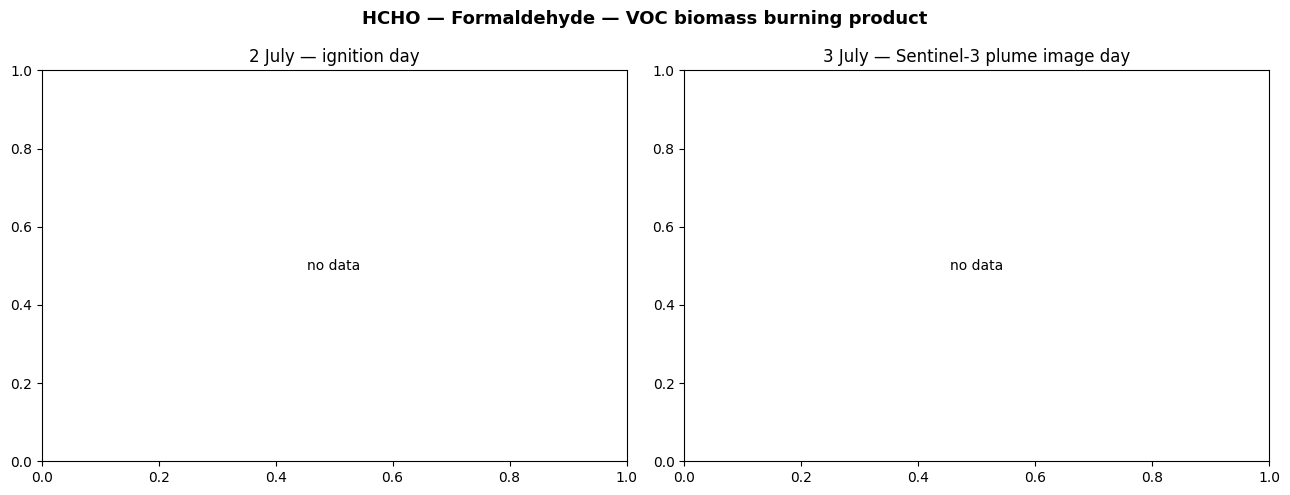

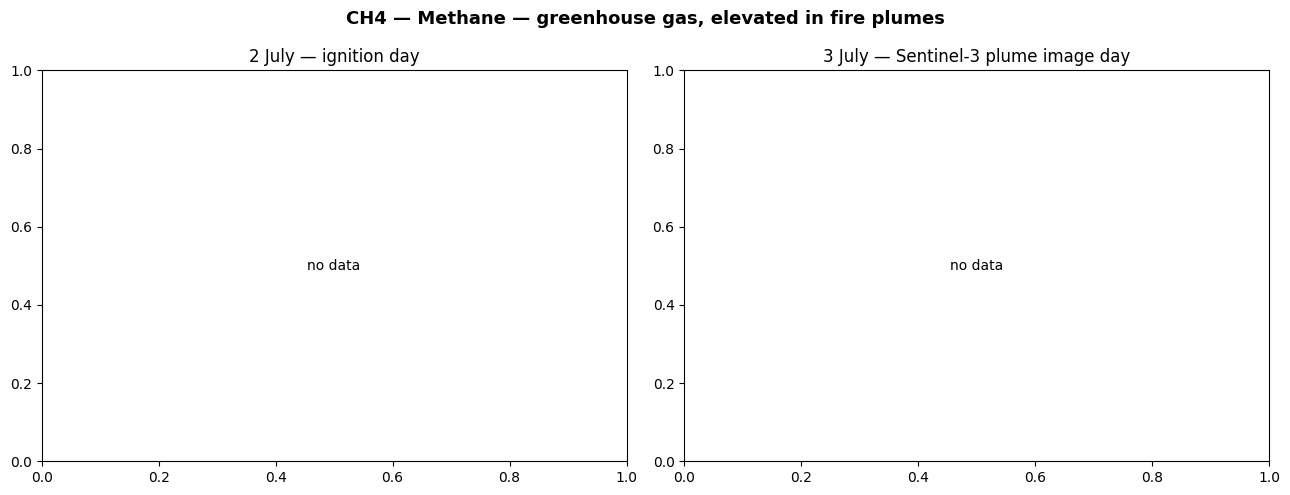

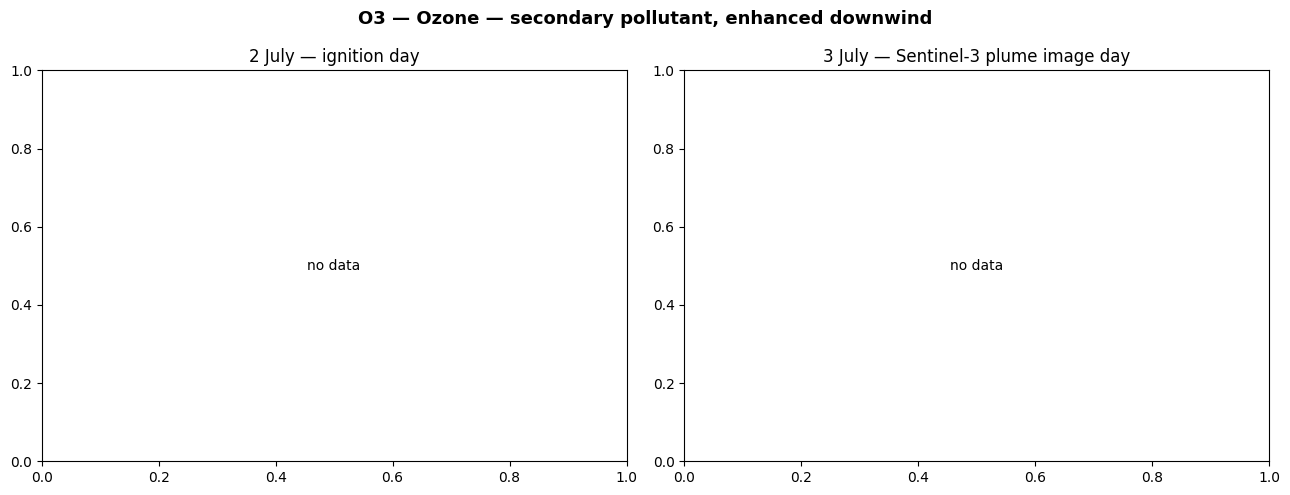

In [5]:
for species, info in SPECIES.items():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{species} — {info['desc']}", fontsize=13, fontweight="bold")

    for ax, (date_str, date_label) in zip(axes, DATES.items()):
        d = results[species][date_str]
        if d["stats"]["n_points"] == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(date_label)
            continue

        sc = ax.scatter(d["lon"], d["lat"], c=d["vals"], cmap=info["cmap"], s=3, marker="s")
        ax.set_title(date_label)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        # Mark Vouzela's approximate location (~40.75N, -8.15E)
        ax.plot(-8.15, 40.75, marker="*", color="cyan", markersize=14, markeredgecolor="black")
        plt.colorbar(sc, ax=ax, label=f"{info['label']} ({info['unit']})", shrink=0.85)

    plt.tight_layout()
    plt.show()


In [6]:
rows = []
for species, info in SPECIES.items():
    d2 = results[species]["2026-07-02"]["stats"]
    d3 = results[species]["2026-07-03"]["stats"]
    pct_change = None
    if d2["mean"] not in (None, 0) and d3["mean"] is not None:
        pct_change = 100 * (d3["mean"] - d2["mean"]) / abs(d2["mean"])

    rows.append({
        "species": species,
        "2_jul_mean": d2["mean"],
        "2_jul_max": d2["max"],
        "3_jul_mean": d3["mean"],
        "3_jul_max": d3["max"],
        "mean_pct_change": pct_change,
        "unit": info["unit"],
    })

summary_df = pd.DataFrame(rows).set_index("species")
print("Summary: 2 July (ignition) vs 3 July (plume image day)")
print(summary_df.to_string(float_format=lambda x: f"{x:,.4g}" if pd.notnull(x) else "n/a"))
summary_df


Summary: 2 July (ignition) vs 3 July (plume image day)
        2_jul_mean 2_jul_max 3_jul_mean 3_jul_max mean_pct_change    unit
species                                                                  
CO            None      None       None      None            None  mol/m²
NO2           None      None       None      None            None  mol/m²
SO2           None      None       None      None            None  mol/m²
HCHO          None      None       None      None            None  mol/m²
CH4           None      None       None      None            None     ppb
O3            None      None       None      None            None  mol/m²


,2_jul_mean,2_jul_max,3_jul_mean,3_jul_max,mean_pct_change,unit
species,,,,,,
CO,None,None,None,None,None,mol/m²
NO2,None,None,None,None,None,mol/m²
SO2,None,None,None,None,None,mol/m²
HCHO,None,None,None,None,None,mol/m²
CH4,None,None,None,None,None,ppb
O3,None,None,None,None,None,mol/m²


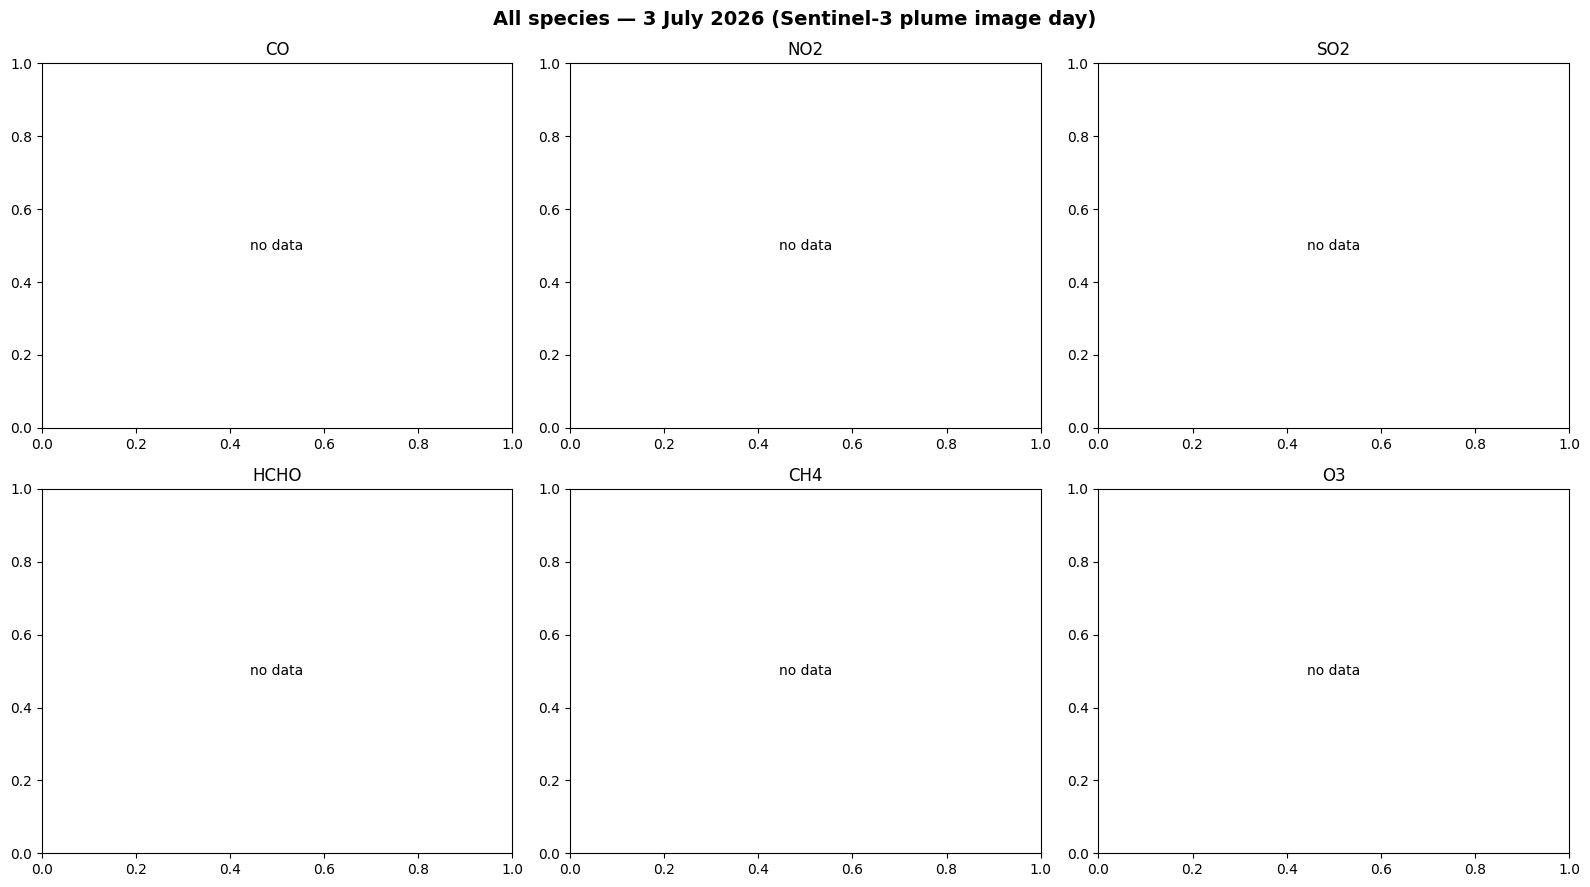

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("All species — 3 July 2026 (Sentinel-3 plume image day)", fontsize=14, fontweight="bold")

for ax, (species, info) in zip(axes.ravel(), SPECIES.items()):
    d = results[species]["2026-07-03"]
    if d["stats"]["n_points"] == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(species)
        continue
    sc = ax.scatter(d["lon"], d["lat"], c=d["vals"], cmap=info["cmap"], s=2, marker="s")
    ax.plot(-8.15, 40.75, marker="*", color="cyan", markersize=10, markeredgecolor="black")
    ax.set_title(f"{species} ({info['unit']})")
    plt.colorbar(sc, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()


## Optional: overlay NASA FIRMS active-fire hotspots

Download VIIRS/MODIS active-fire points for 2–3 July 2026 over Portugal from
https://firms.modaps.eosdis.nasa.gov/download/ (CSV format) and save as
`data/firms_hotspots.csv`. Re-run the cell below once that file exists to
overlay fire detections on top of the CO map for source attribution.


In [8]:
firms_path = os.path.join(DATA_DIR, "firms_hotspots.csv")

if os.path.exists(firms_path):
    firms = pd.read_csv(firms_path)
    print(f"Loaded {len(firms)} FIRMS hotspot detections")

    d = results["CO"]["2026-07-03"]
    fig, ax = plt.subplots(figsize=(9, 7))
    if d["stats"]["n_points"] > 0:
        sc = ax.scatter(d["lon"], d["lat"], c=d["vals"], cmap="inferno", s=3, marker="s", alpha=0.7)
        plt.colorbar(sc, ax=ax, label="CO total column (mol/m²)")
    ax.scatter(firms["longitude"], firms["latitude"], c="lime", s=8, marker="x", label="FIRMS fire detection")
    ax.plot(-8.15, 40.75, marker="*", color="cyan", markersize=14, markeredgecolor="black", label="Vouzela")
    ax.set_title("CO plume (3 July 2026) with FIRMS active-fire hotspots")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"No FIRMS file found at {firms_path} — skipping overlay.")
    print("Download one from https://firms.modaps.eosdis.nasa.gov/download/ to enable this cell.")


No FIRMS file found at ../data/firms_hotspots.csv — skipping overlay.
Download one from https://firms.modaps.eosdis.nasa.gov/download/ to enable this cell.


## Interpretation notes

- **CO and NO₂** are the most direct combustion tracers and should show the
  clearest enhancement over/downwind of Vouzela on 3 July versus 2 July.
- **SO2** is often noisy/sparse for biomass burning (it's more diagnostic for
  volcanic/industrial sources) — don't be surprised by low pixel counts.
- **HCHO** (VOC oxidation product) typically lags CO/NO₂ slightly as the
  plume ages chemically downwind.
- **CH4** enhancements from a single wildfire are usually subtle relative to
  the background column — look for small but consistent increases along the
  plume axis rather than dramatic spikes.
- **O3** can go either way near fresh smoke (titration by NO can suppress it
  near the source; downwind photochemistry can enhance it).
- Cross-reference any strong CO/NO₂ enhancement with the FIRMS overlay above
  to confirm it traces back to the Vouzela source rather than another
  regional fire (Barcelos, Cinfães, Castelo de Paiva were also active in the
  same window).
